# Group-level apples-to-apples comparison (Rutherford 2023 eLife design)

`5_deseq2_group_comparison.ipynb` compared normative_union (K=1 union of per-patient BH-significant
genes across a whole cohort) against DESeq2's group test -- different statistical units (min-p
aggregation vs one p-value per gene), which confounds the comparison (see
`Benchmark/FDR_THRESHOLD_RATIONALE.md`).

This notebook applies DESeq2's OWN statistical design -- one p-value per gene from a single
group-level test, BH-FDR, hypergeometric-vs-OT-reference -- to normative Z-scores instead of raw
counts, isolating whether deviation scores carry more disease signal than raw counts at the SAME
statistical unit:

- **Gene level**: DESeq2 Wald stat vs normative group Stouffer's Z (`db_hit_compare.group_level_z_test`)
- **Pathway level**: real preranked GSEA (Subramanian 2005) on each ranking, replacing the ad hoc
  mean-Z+permutation-null scorer used elsewhere (`db_hit_compare.group_level_pathway_gsea`)

This does NOT replace `5_deseq2_group_comparison.ipynb`'s normative_union results -- that notebook
answers "does per-patient individual-level detection find real signal"; this one answers "does the
deviation-score feature itself carry more group-separable signal than the raw count feature."

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))
from viz_style import apply_style
apply_style()

import MixedEffectsModeling.config as config
from MixedEffectsModeling.Benchmark import db_hit_compare as dc

BENCH = config.ROOT / 'MixedEffectsModeling' / 'Benchmark'

## 1. Gene level -- Stouffer's Z vs DESeq2 Wald stat

In [2]:
GENE_Z_PATH = BENCH / 'group_level_z_test.csv'
if GENE_Z_PATH.exists():
    gene_z = pd.read_csv(GENE_Z_PATH)
else:
    gene_z = dc.group_level_z_test()
    gene_z.to_csv(GENE_Z_PATH, index=False)

print('significant phenotypes (hypergeometric padj<0.05) by method x q:')
display(gene_z.groupby(['method', 'q'])['sig_fdr05'].agg(n_sig='sum', n_total='size'))

significant phenotypes (hypergeometric padj<0.05) by method x q:


n_sig  n_total
method              q                   
deseq2_no_covariate 0.05      9       13
                    0.10      9       13
                    0.15      7       13
                    0.20      9       13
normative_group_z   0.05      7       14
                    0.10      8       14
                    0.15      8       14
                    0.20      7       14

In [3]:
q05 = gene_z[gene_z.q == 0.05].sort_values(['phenotype', 'method']).reset_index(drop=True)
display(q05[['phenotype', 'method', 'n_sig', 'overlap', 'ref_size', 'pval', 'padj', 'sig_fdr05']])

,phenotype,method,n_sig,overlap,ref_size,pval,padj,sig_fdr05
0,Colorectal Cancer,deseq2_no_covariate,10041,192,300,1.559889e-06,5.615602e-06,True
1,Colorectal Cancer,normative_group_z,6407,95,300,6.097257e-01,6.719426e-01,False
2,Esophagus Cancer,deseq2_no_covariate,432,12,300,3.201287e-02,5.160283e-02,False
3,Esophagus Cancer,normative_group_z,3535,52,300,6.083093e-01,6.719426e-01,False
4,HIV,deseq2_no_covariate,52,4,299,7.734114e-03,1.465411e-02,True
5,HIV,normative_group_z,1747,56,299,4.634924e-08,3.337145e-07,True
6,HIV + Tuberculosis,deseq2_no_covariate,321,23,300,7.728667e-10,1.669392e-08,True
7,HIV + Tuberculosis,normative_group_z,1743,54,300,2.848705e-07,1.398455e-06,True
8,Liver Cancer,deseq2_no_covariate,1280,34,300,9.876276e-04,1.976551e-03,True
9,Liver Cancer,normative_group_z,4842,110,300,1.185445e-06,4.572431e-06,True


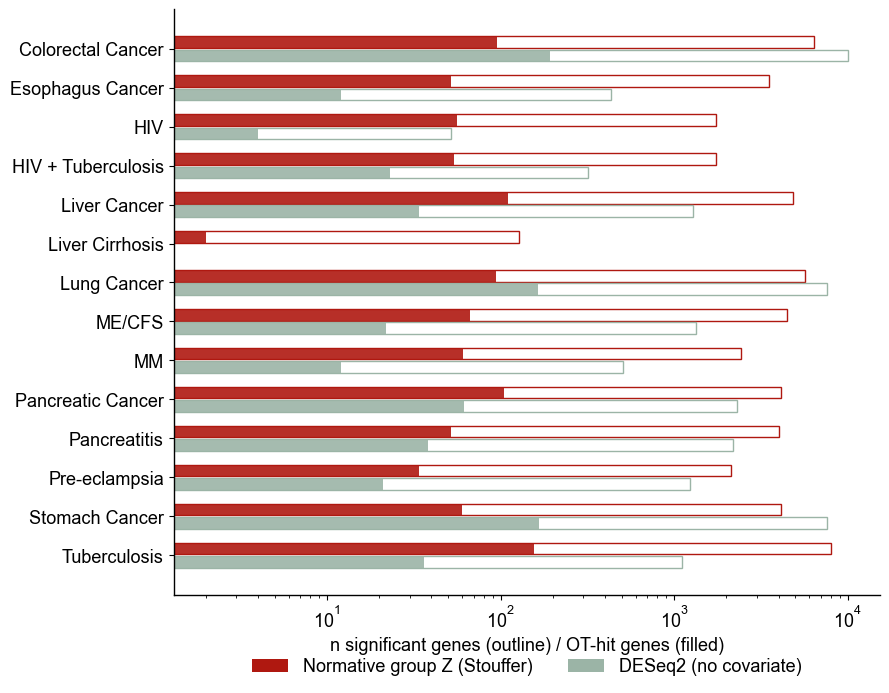

In [4]:
rates_q05 = q05.rename(columns={'overlap': 'n_db'}).copy()
rates_q05['has_ot_ref'] = rates_q05['ref_size'] > 0
rates_q05['db_hit_rate'] = rates_q05['n_db'] / rates_q05['n_sig'].replace(0, np.nan)

fig, ax = plt.subplots(figsize=(9, 7))
sub = rates_q05[rates_q05.has_ot_ref]
phenos = sorted(sub.phenotype.unique(), reverse=True)
methods = ['normative_group_z', 'deseq2_no_covariate']
colors = {'normative_group_z': '#af1810', 'deseq2_no_covariate': '#9bb4a6'}
y = np.arange(len(phenos))
for j, m in enumerate(methods):
    offset = (0.5 - j) * 0.35
    n_sig_v = [sub[(sub.phenotype == p) & (sub.method == m)]['n_sig'].sum() for p in phenos]
    n_db_v = [sub[(sub.phenotype == p) & (sub.method == m)]['n_db'].sum() for p in phenos]
    ax.barh(y + offset, n_sig_v, height=0.3, facecolor='none', edgecolor=colors[m], linewidth=1)
    ax.barh(y + offset, n_db_v, height=0.3, facecolor=colors[m], edgecolor='none', alpha=0.9)
ax.set_yticks(y)
ax.set_yticklabels(phenos)
ax.set_xscale('log')
ax.set_xlabel('n significant genes (outline) / OT-hit genes (filled)')
handles = [plt.Rectangle((0, 0), 1, 1, facecolor=colors[m]) for m in methods]
ax.legend(handles, ['Normative group Z (Stouffer)', 'DESeq2 (no covariate)'], loc='upper center',
          bbox_to_anchor=(0.5, -0.08), ncol=2, frameon=False)
for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
fig.savefig(BENCH / 'Figures' / 'group_z_gene_bars.png', bbox_inches='tight', dpi=300)

## 2. Pathway level -- preranked GSEA on the same two rankings

`gp.prerank` (Subramanian 2005 weighted running-sum + gene-label permutation null), same
KEGG_2021_Human + Reactome_2022 housekeeping-filtered library as `4_gene_enrichment.ipynb`.
q<0.05 = confirmatory, q<0.25 = GSEA's own discovery-tier convention
(`Benchmark/FDR_THRESHOLD_RATIONALE.md`).

In [5]:
PATH_GSEA_PATH = BENCH / 'pathway_gsea_db_hit_rates.csv'
if PATH_GSEA_PATH.exists():
    path_gsea = pd.read_csv(PATH_GSEA_PATH)
else:
    path_gsea = dc.group_level_pathway_gsea()

display(path_gsea[path_gsea.has_ot_ref].sort_values(['phenotype', 'method']).reset_index(drop=True))

,phenotype,method,n_sig,n_db,db_hit_rate,has_ot_ref
0,Colorectal Cancer,deseq2_no_cov_gsea,31,13,0.419,True
1,Colorectal Cancer,deseq2_no_cov_gsea_q025,250,80,0.320,True
2,Colorectal Cancer,normative_group_gsea,358,83,0.232,True
3,Colorectal Cancer,normative_group_gsea_q025,700,211,0.301,True
4,Esophagus Cancer,deseq2_no_cov_gsea,63,39,0.619,True
5,Esophagus Cancer,deseq2_no_cov_gsea_q025,273,149,0.546,True
6,Esophagus Cancer,normative_group_gsea,377,86,0.228,True
7,Esophagus Cancer,normative_group_gsea_q025,687,172,0.250,True
8,HIV,deseq2_no_cov_gsea,7,4,0.571,True
9,HIV,deseq2_no_cov_gsea_q025,58,19,0.328,True


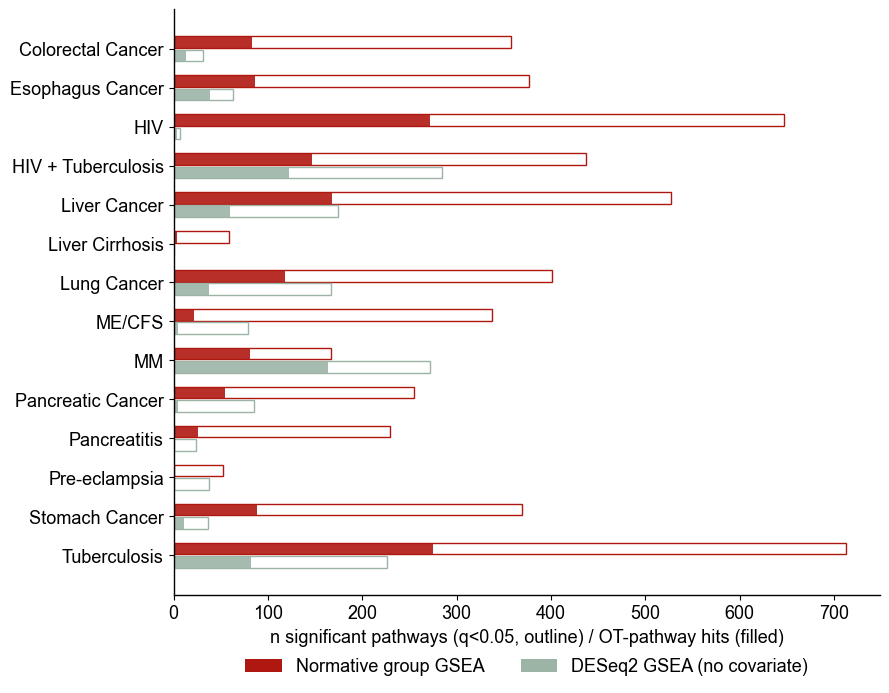

In [6]:
sub = path_gsea[path_gsea.has_ot_ref & path_gsea.method.isin(
    ['normative_group_gsea', 'deseq2_no_cov_gsea'])]
phenos = sorted(sub.phenotype.unique(), reverse=True)
methods = ['normative_group_gsea', 'deseq2_no_cov_gsea']
colors = {'normative_group_gsea': '#af1810', 'deseq2_no_cov_gsea': '#9bb4a6'}
y = np.arange(len(phenos))
fig, ax = plt.subplots(figsize=(9, 7))
for j, m in enumerate(methods):
    offset = (0.5 - j) * 0.35
    n_sig_v = [sub[(sub.phenotype == p) & (sub.method == m)]['n_sig'].sum() for p in phenos]
    n_db_v = [sub[(sub.phenotype == p) & (sub.method == m)]['n_db'].sum() for p in phenos]
    ax.barh(y + offset, n_sig_v, height=0.3, facecolor='none', edgecolor=colors[m], linewidth=1)
    ax.barh(y + offset, n_db_v, height=0.3, facecolor=colors[m], edgecolor='none', alpha=0.9)
ax.set_yticks(y)
ax.set_yticklabels(phenos)
ax.set_xlabel('n significant pathways (q<0.05, outline) / OT-pathway hits (filled)')
handles = [plt.Rectangle((0, 0), 1, 1, facecolor=colors[m]) for m in methods]
ax.legend(handles, ['Normative group GSEA', 'DESeq2 GSEA (no covariate)'], loc='upper center',
          bbox_to_anchor=(0.5, -0.08), ncol=2, frameon=False)
for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
fig.savefig(BENCH / 'Figures' / 'group_gsea_pathway_bars.png', bbox_inches='tight', dpi=300)